# Project 1 — XGBoost Regressor
## Household Energy Consumption Prediction

Predicting hourly energy consumption (kWh) from outdoor temperature, humidity, occupancy, and hour of day.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
np.random.seed(42)
pd.set_option('display.max_columns', None)


## 1. Generate / Load Data

In [2]:
n = 900
temperature = np.random.normal(20, 8, n)
humidity = np.random.uniform(20, 90, n)
occupancy = np.random.poisson(2, n)
hour_of_day = np.random.randint(0, 24, n)

# consumption has a U-shape with temperature (heating AND cooling cost) and peaks morning/evening
temp_effect = 0.01*(temperature-20)**2
hour_effect = 2*np.sin((hour_of_day-6)/24*2*np.pi) + 2

consumption = (3 + temp_effect + 0.3*occupancy + hour_effect + 0.01*humidity
               + np.random.normal(0, 0.5, n)).clip(0.5, None)

df = pd.DataFrame({'temperature': temperature, 'humidity': humidity, 'occupancy': occupancy,
                    'hour_of_day': hour_of_day, 'consumption': consumption})
df.head()


,temperature,humidity,occupancy,hour_of_day,consumption
0,23.973713,31.253193,0,21,4.025038
1,18.893886,77.257692,2,10,8.028031
2,25.181508,78.249392,1,19,6.554339
3,32.184239,55.522741,2,18,7.673487
4,18.126773,20.447011,4,8,8.071443


## 2. Preprocessing

In [3]:
X = df.drop('consumption', axis=1)
y = df['consumption']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## 3. Train Model

In [4]:
from xgboost import XGBRegressor

model = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=4,
                      subsample=0.8, colsample_bytree=0.8,
                      reg_alpha=0.1, reg_lambda=1.0, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


## 4. Evaluate

In [5]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))


MAE: 0.4409019526468483
RMSE: 0.657976185123338
R2 Score: 0.8765990385846202


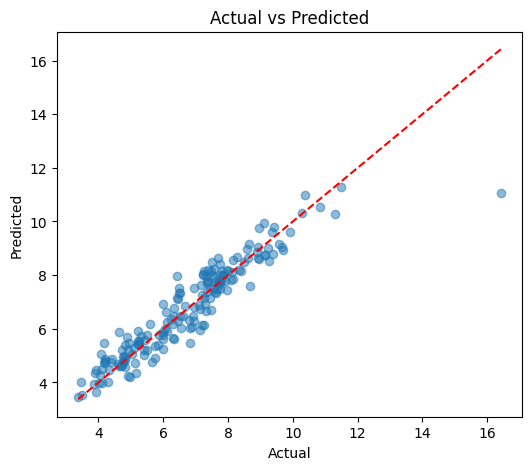

In [6]:
plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred, alpha=0.5)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'r--')
plt.xlabel('Actual'); plt.ylabel('Predicted'); plt.title('Actual vs Predicted')
plt.show()


## Takeaways
- Temperature has a non-linear (U-shaped) effect here — a plain Linear Regression would badly underfit this. Compare R² between the two to see the gap.
- Check `model.feature_importances_` and try `xgboost.plot_importance(model)`.
- Next steps: add an `eval_set` + `early_stopping_rounds` to auto-tune `n_estimators`.



